In [20]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.tools import tool
import yfinance as yf
from tavily import TavilyClient
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


In [2]:
class AgentState(TypedDict):
    ticker: str
    analysis_data: Annotated[dict, operator.ior]
    final_recommendation: str
    loop_count: int  

In [27]:
import os

tavily = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))

@tool
def search_market_research(ticker: str) -> str:
    """Searches for structural business updates, sector competition, and market share for a stock."""
    query = f"{ticker} stock structural analysis business model market share 2026"
    return str(tavily.search(query=query, topic="general"))

@tool
def search_news_sentiment(ticker: str) -> str:
    """Searches for the latest news headlines and market sentiment surrounding a stock."""
    query = f"{ticker} stock news sentiment investor relations"
    return str(tavily.search(query=query, topic="news", days=3))

@tool
def get_stock_metrics(ticker: str) -> str:
    """Fetches real-time financial metrics, P/E ratio, and price boundaries from Yahoo Finance."""
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        hist = stock.history(period="1mo")
        current_price = info.get('currentPrice', hist['Close'].iloc[-1] if not hist.empty else "N/A")
        
        return f"""
        Current Price: ${current_price}
        52 Week High: ${info.get('fiftyTwoWeekHigh')}
        52 Week Low: ${info.get('fiftyTwoWeekLow')}
        Trailing P/E: {info.get('trailingPE')}
        Forward P/E: {info.get('forwardPE')}
        """
    except Exception as e:
        return f"Error gathering metrics: {str(e)}"

In [28]:
llm = ChatOpenAI(model='gpt-5-nano')

def market_research_node(state: AgentState):
    ticker = state["ticker"]
    current_loops = state.get("loop_count", 0)
    
    # Run tool execution
    tool_output = search_market_research.invoke({"ticker": ticker})
    
    prompt = f"Synthesize this research data for {ticker}. Focus on competitive threats: {tool_output}"
    response = llm.invoke(prompt)
    
    return {
        "analysis_data": {"market_research": response.content},
        "loop_count": current_loops + 1 # Initialize or increment loop tracker
    }

def sentiment_analysis_node(state: AgentState):
    ticker = state["ticker"]
    tool_output = search_news_sentiment.invoke({"ticker": ticker})
    
    prompt = f"Determine the core market narrative and sentiment from this data for {ticker}: {tool_output}"
    response = llm.invoke(prompt)
    
    return {"analysis_data": {"sentiment": response.content}}

def stock_performance_node(state: AgentState):
    ticker = state["ticker"]
    tool_output = get_stock_metrics.invoke({"ticker": ticker})
    
    prompt = f"Analyze if the stock pricing metrics look fundamentally overvalued or undervalued: {tool_output}"
    response = llm.invoke(prompt)
    
    return {"analysis_data": {"performance": response.content}}

In [29]:
def aggregator_node(state: AgentState):
    data = state["analysis_data"]
    ticker = state["ticker"]
    
    eval_prompt = f"""
    You are a risk management supervisor. Review our collected data for {ticker}:
    Research: {data.get('market_research')}
    Sentiment: {data.get('sentiment')}
    Performance: {data.get('performance')}
    
    If ANY of the components above are missing data, vague, or failed, reply exactly with: 'INCOMPLETE_DATA'.
    Otherwise, finalize the analysis and categorize the stock into exactly one of these buckets:
    - Strong Buy (Risky)
    - Strong Buy (Moderate Risk)
    - Strong Buy (No Risk)
    - Do Not Buy At All
    
    Format your final response cleanly with RECOMMENDATION and JUSTIFICATION if complete.
    """
    response = llm.invoke(eval_prompt)
    return {"final_recommendation": response.content}

In [30]:
def should_continue(state: AgentState):
    # If the aggregator asked for more data, and we haven't hit our 3-loop limit
    if "INCOMPLETE_DATA" in state["final_recommendation"]:
        # If we have run the loop fewer than 3 times (each parallel pass increments loop_count by 1 via the research node)
        if state.get("loop_count", 0) < 3:
            print(f"⚠️ Data incomplete. Re-iterating workflow (Iteration {state['loop_count']}/3)...")
            return "retry"
        else:
            print("🚨 Max iterations (3) reached. Forcing finalization with existing metrics.")
            return "finalize"
            
    return "finalize"

In [31]:
def ticker_standardizer_node(state: AgentState):
    user_input = state["ticker"]
    
    prompt = f"""
    The user wants to analyze: "{user_input}".
    Identify the official Yahoo Finance ticker symbol for this company. 
    If it is an international company, default to its US ADR ticker if available (e.g., INFY for Infosys, or TM for Toyota), otherwise use its local suffix (e.g., RELIANCE.NS).
    
    Respond with ONLY the ticker symbol. Do not include spaces, periods, or extra text.
    Example Response: AAPL
    """
    
    cleaned_ticker = llm.invoke(prompt).content.strip()
    print(f"🎯 Standardized '{user_input}' to ticker: '{cleaned_ticker}'")
    
    return {"ticker": cleaned_ticker}

In [32]:
def retry_gateway_node(state: AgentState):
    print("🔁 Router Gateway: fan-out to parallel workers...")
    return state

In [33]:
workflow = StateGraph(AgentState)

# 1. Add all nodes (including the new gateway)
workflow.add_node("market_research", market_research_node)
workflow.add_node("sentiment_analysis", sentiment_analysis_node)
workflow.add_node("stock_performance", stock_performance_node)
workflow.add_node("aggregator", aggregator_node)
workflow.add_node("retry_gateway", retry_gateway_node) # <- Added
workflow.add_node("ticker_standardizer", ticker_standardizer_node)

# 2. Start parallel execution
workflow.add_edge(START, "ticker_standardizer")
workflow.add_edge('ticker_standardizer', "market_research")
workflow.add_edge('ticker_standardizer', "sentiment_analysis")
workflow.add_edge('ticker_standardizer', "stock_performance")

# 3. Combine parallel executions into aggregator
workflow.add_edge("market_research", "aggregator")
workflow.add_edge("sentiment_analysis", "aggregator")
workflow.add_edge("stock_performance", "aggregator")

# 4. Define Conditional Routing (Now map "retry" to a single string node!)
workflow.add_conditional_edges(
    "aggregator",
    should_continue,
    {
        "retry": "retry_gateway",  # <- Changed from a list to a single node name
        "finalize": END
    }
)

# 5. Connect the gateway back to parallel workers
workflow.add_edge("retry_gateway", "market_research")
workflow.add_edge("retry_gateway", "sentiment_analysis")
workflow.add_edge("retry_gateway", "stock_performance")


# 1. Initialize the memory saver checkpointer
memory = MemorySaver()

# 2. Compile the graph with the checkpointer explicitly attached
app = workflow.compile(checkpointer=memory)

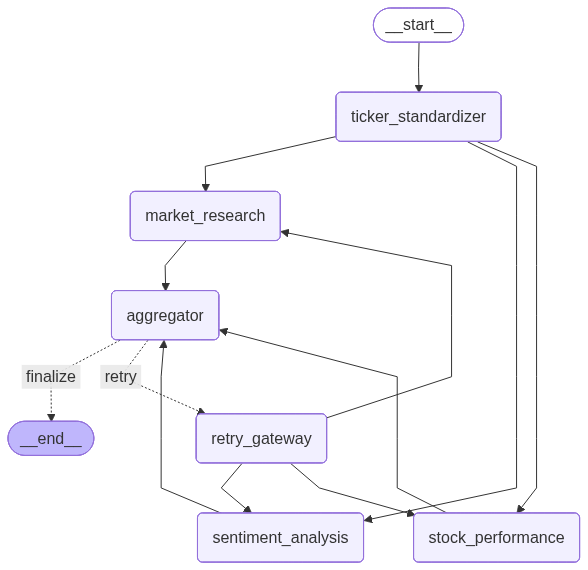

In [34]:
app

In [39]:
# 1. Define your inputs (Make sure to use an actual ticker like INFY or INFY.NS for Tech Mahindra)
inputs = {
    "ticker": "Tech Mahindra", 
    "loop_count": 0, 
    "analysis_data": {}
}

# 2. Define your thread configuration for the checkpointer
config = {"configurable": {"thread_id": "stock_analysis_session_01"}}

print("🚀 Starting Stock Analysis Workflow...")
print("==================================================\n")

# 3. Stream the execution live to the terminal
for chunk in app.stream(inputs, config=config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"🟩 NODE EXECUTED: [{node_name}]")
        
        # Log what data was added to the state in this step
        if "analysis_data" in node_output:
            added_metrics = list(node_output["analysis_data"].keys())
            print(f"   💾 Added analysis chunk for: {added_metrics}")
            
        if "loop_count" in node_output:
            print(f"   🔄 Current loop iteration: {node_output['loop_count']}/3")
            
        if "final_recommendation" in node_output:
            print(f"   🏁 Output object generated.")
            
        print("-" * 50)

print("\n🏁 Workflow execution finished!")

🚀 Starting Stock Analysis Workflow...

🎯 Standardized 'Tech Mahindra' to ticker: 'TMH'
🟩 NODE EXECUTED: [ticker_standardizer]
--------------------------------------------------
🟩 NODE EXECUTED: [sentiment_analysis]
   💾 Added analysis chunk for: ['sentiment']
--------------------------------------------------
🟩 NODE EXECUTED: [market_research]
   💾 Added analysis chunk for: ['market_research']
   🔄 Current loop iteration: 1/3
--------------------------------------------------
🟩 NODE EXECUTED: [stock_performance]
   💾 Added analysis chunk for: ['performance']
--------------------------------------------------
⚠️ Data incomplete. Re-iterating workflow (Iteration 1/3)...
🟩 NODE EXECUTED: [aggregator]
   🏁 Output object generated.
--------------------------------------------------
🔁 Router Gateway: fan-out to parallel workers...
🟩 NODE EXECUTED: [retry_gateway]
   💾 Added analysis chunk for: ['market_research', 'sentiment', 'performance']
   🔄 Current loop iteration: 1/3
   🏁 Output object

In [41]:
# Fetch the final snapshot from memory
final_state = app.get_state(config)
recommendation = final_state.values.get("final_recommendation")

print("\n" + "="*50)
print("🎯 FINAL INVESTMENT RATING")
print("="*50)
if recommendation:
    print(recommendation)
else:
    print("❌ Something went wrong. No recommendation found in this thread.")
print("="*50)


🎯 FINAL INVESTMENT RATING
INCOMPLETE_DATA
